In [2]:
%load_ext autoreload
%autoreload 2

### Setup

In [3]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [4]:
# pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [5]:
df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet')

In [6]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()

TASKS = [t for t in TASKS if 'mmlu' not in t]

print(MODELS)
print(TASKS)
print(MIXES)
# print(STEPS)

['peteish13-highlr', 'peteish7', 'phi-1_5', 'peteish-moreeval-1B-2xC', 'peteish-moreeval-190M-2xC', 'peteish-moreeval-rerun-370M-1xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-760M-0.5xC', 'peteish-moreeval-1B-5xC', 'falcon_and_cc_eli5_oh_top10p-1B-5xC', 'fineweb_edu_dedup-1B-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'falcon_and_cc-1B-5xC', 'no_flan-1B-5xC', 'prox_fineweb_pro-1B-5xC', 'falcon_and_cc_eli5_oh_top20p-1B-5xC', 'baseline-1B-5xC', 'falcon_and_cc_tulu_qc_top10-1B-5xC', 'no_math_no_code-1B-5xC', 'c4-1B-5xC', 'redpajama-1B-5xC', 'no_code-1B-5xC', 'no_reddit-1B-5xC', 'falcon-1B-5xC', 'peteish-moreeval-rerun-760M-1xC', 'peteish-moreeval-370M-2xC', 'DCLM-baseline-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-1B-5xC', 'dolma-v1-6-and-sources-baseline-1B-5xC', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'peteish-moreeval-760M-10xC', 'peteish-moreeval-3B-10xC', 'peteish-moreeval-rerun-3B-1xC', 'peteish-moreeval-rerun-1B-1xC', 'peteish-m

In [7]:
# models, scores = get_nd_array(df, 'model', 'acc_per_char', task='arc_challenge:distractors')
# models, scores = get_nd_array(df, ['model', 'mix'], 'acc_per_char', task='arc_challenge:distractors')

### Measure 1: Predictability (Rel Error @ 7B)

MMLU & $Acc(L) = -0.74 / (1 + \exp (-4.83(L - 0.62))) + 1.00$ \\
HellaSwag & $Acc(L) = -0.73 / (1 + \exp (-12.74(L - 0.77))) + 0.99$ \\
ARC-Easy & $Acc(L) = -0.65 / (1 + \exp (-4.13(L - 0.74))) + 1.00$ \\
ARC-Challenge & $Acc(L) = -0.78 / (1 + \exp (-5.91(L - 0.71))) + 1.00$ \\
BoolQ & $Acc(L) = -0.44 / (1 + \exp (-19.58(L - 0.30))) + 1.00$ \\
CommonsenseQA & $Acc(L) = -0.86 / (1 + \exp (-2.21(L - 1.13))) + 1.00$ \\
OpenBookQA & $Acc(L) = -0.79 / (1 + \exp (-4.31(L - 1.08))) + 1.00$ \\
PIQA & $Acc(L) = -0.46 / (1 + \exp (-5.03(L - 0.96))) + 1.00$ \\
Social IQa & $Acc(L) = -0.60 / (1 + \exp (-7.16(L - 0.89))) + 1.00$ \\
Winogrande & $Acc(L) = -0.50 / (1 + \exp (-16.16(L - 1.45))) + 0.99$ \\

Mean relative error: 1.79%


/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling/step2.py:349: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[j][i].legend().remove()


Task Name | Actual Value | Predicted Value | Relative Error
mmlu_avg_test_5shot | 0.49 | 0.49 | +0.3% | Acc(L) = -0.74 / (1 + \exp (-4.83(L - 0.62))) + 1.00
hellaswag_val_5shot | 0.81 | 0.82 | +1.1% | Acc(L) = -0.73 / (1 + \exp (-12.74(L - 0.77))) + 0.99
arc_easy_test_5shot | 0.85 | 0.81 | -4.5% | Acc(L) = -0.65 / (1 + \exp (-4.13(L - 0.74))) + 1.00
arc_challenge_test_5shot | 0.62 | 0.57 | -7.6% | Acc(L) = -0.78 / (1 + \exp (-5.91(L - 0.71))) + 1.00
boolq_val_5shot | 0.85 | 0.88 | +4.3% | Acc(L) = -0.44 / (1 + \exp (-19.58(L - 0.30))) + 1.00
csqa_val_5shot | 0.73 | 0.72 | -1.0% | Acc(L) = -0.86 / (1 + \exp (-2.21(L - 1.13))) + 1.00
openbookqa_test_5shot | 0.49 | 0.45 | -8.2% | Acc(L) = -0.79 / (1 + \exp (-4.31(L - 1.08))) + 1.00
piqa_val_5shot | 0.82 | 0.80 | -2.3% | Acc(L) = -0.46 / (1 + \exp (-5.03(L - 0.96))) + 1.00
socialiqa_val_5shot | 0.60 | 0.63 | +4.7% | Acc(L) = -0.60 / (1 + \exp (-7.16(L - 0.89))) + 1.00
winogrande_val_5shot | 0.77 | 0.59 | -23.7% | Acc(L) = -0.50 / (1 + \exp

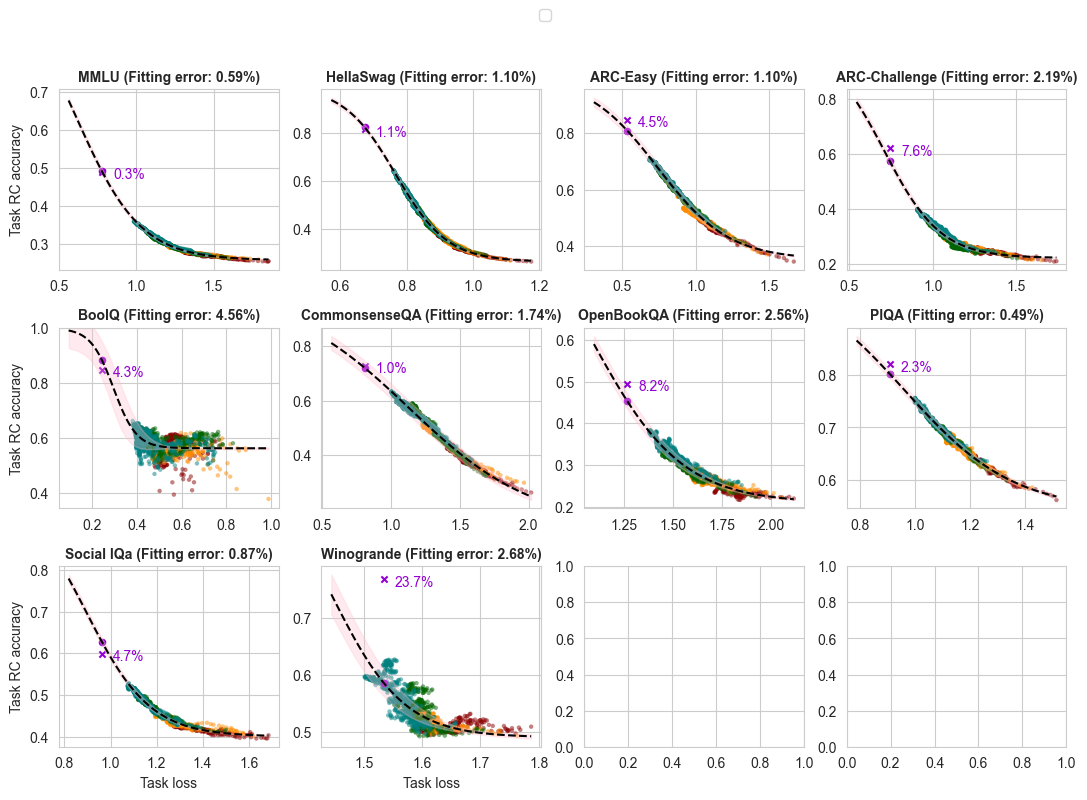

In [11]:
# ladder_models = [m for m in models if 'peteish-moreeval' in m]

# Input: [parameters, tokens, task loss, task accuracy, target model]
# Output: [rel error, abs error]

from scaling.step2 import main as step2_main

os.chdir('/Users/dhei/ai2/new-evals/olmo-repos/olmo')

# Run step 2 only
step2_args = [
    "-k", "v2_main_variance",
    "-c", "scripts/scaling/final_7b_only.json",
    "-o", "/tmp/step2_main.pdf",
    "--skip_perc", "0.1",
    "--moving_avg", "5",
]
sys.argv = [sys.argv[0]] + step2_args
step2_df = step2_main()

# python scripts/scaling/step2.py -k v2_main -c scripts/scaling/step2.json -o figure/peteish-moreeval/step2_main.pdf --skip_perc 0.1 --moving_avg 5


### Measure 2: Seperability (% sig @ 1B)

In [37]:
from stats import compute_significance
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]

In [44]:
tasks = TASKS # ['arc_easy']

sig_results, _ = compute_significance(df, MODEL_LIST_MIXES, 'acc_per_char', tasks=tasks)
# sig_results, fig = compute_significance(df, MODEL_LIST_MIXES, 'acc_per_char', tasks=tasks, do_plot=True)

Computing pairwise comparisons:   0%|          | 0/22 [00:00<?, ?it/s]

Computing pairwise comparisons:  59%|█████▉    | 13/22 [00:05<00:03,  2.38it/s]

Computing pairwise comparisons:  73%|███████▎  | 16/22 [00:06<00:02,  2.33it/s]

Computing pairwise comparisons: 100%|██████████| 22/22 [00:08<00:00,  2.65it/s]


In [39]:
from table import display_task_variants

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='1B')

% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,90.0%,91.3% (+1.3%),92.6% (+2.6%),85.5% (-4.5%)
hellaswag,87.9%,--,--,80.3% (-7.6%)
csqa,79.7%,--,--,52.6% (-27.1%)
arc_challenge,75.3%,76.8% (+1.6%),89.5% (+14.2%),77.6% (+2.4%)
boolq,71.1%,--,--,79.7% (+8.7%)
socialiqa,56.6%,--,--,44.5% (-12.1%)
openbookqa,51.6%,--,--,53.9% (+2.4%)
piqa,34.2%,--,--,31.1% (-3.2%)
winogrande,24.7%,--,--,26.3% (+1.6%)


### Measure 3: Smoothness (Total Variation @ 1B)

In [40]:
from stats import calc_total_variation

In [41]:
tv_results = pd.DataFrame(index=['total_variation'], columns=TASKS)

for task in TASKS:
    models, scores = get_nd_array(df, 'step', 'acc_per_char', model='peteish-moreeval-1B-5xC', task=task) # (step, instance)

    if len(scores) <= 1: continue

    acc = scores.mean(axis=1) # (step)
    
    tv_results.loc['total_variation', task] = calc_total_variation(acc, improvement=True) * 100

In [42]:
print(f'TV-I for {scores.shape[0]} intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

TV-I for 164 intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,--,--,0.18 (+0.01)
piqa,0.37,--,--,0.38 (+0.01)
socialiqa,0.50,--,--,0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.58 (+0.05),0.43 (-0.10)
csqa,0.56,--,--,0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.53 (-0.15),0.72 (+0.05)
openbookqa,0.93,--,--,1.03 (+0.10)
boolq,3.56,--,--,1.13 (-2.43)
